# Exploring the data of round 1

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Fair Value Proxy

In [91]:
# --- Fair Value Proxy: data loading ---

PRICE_FILES = [
    "../data/ROUND1/prices_round_1_day_-2.csv",
    "../data/ROUND1/prices_round_1_day_-1.csv",
    "../data/ROUND1/prices_round_1_day_0.csv",
]

PRODUCTS = ["ASH_COATED_OSMIUM", "INTARIAN_PEPPER_ROOT"]

price_dfs = []
for day_idx, path in zip([-2, -1, 0], PRICE_FILES):
    df = pd.read_csv(path, sep=";")
    df["day"] = day_idx
    price_dfs.append(df)

prices = pd.concat(price_dfs, ignore_index=True)

# convenient absolute time axis across all 3 days
# timestamps are usually 0..999900 in steps of 100 inside each day
prices["global_ts"] = prices["day"] * 1_000_000 + prices["timestamp"]

prices = prices.sort_values(["product", "day", "timestamp"]).reset_index(drop=True)

print(prices["product"].value_counts())
display(prices.head())

product
ASH_COATED_OSMIUM       30000
INTARIAN_PEPPER_ROOT    30000
Name: count, dtype: int64


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,global_ts
0,-2,0,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,10010.0,25.0,NaN,NaN,NaN,NaN,10010.0,0.0,-2000000
1,-2,100,ASH_COATED_OSMIUM,9992.0,15.0,NaN,NaN,NaN,NaN,10008.0,15.0,10011.0,20.0,NaN,NaN,10000.0,0.0,-1999900
2,-2,200,ASH_COATED_OSMIUM,9992.0,15.0,9989.0,30.0,NaN,NaN,10008.0,15.0,10010.0,30.0,NaN,NaN,10000.0,0.0,-1999800
3,-2,300,ASH_COATED_OSMIUM,9992.0,13.0,9989.0,26.0,NaN,NaN,10008.0,13.0,10010.0,26.0,NaN,NaN,10000.0,0.0,-1999700
4,-2,400,ASH_COATED_OSMIUM,9992.0,15.0,NaN,NaN,NaN,NaN,10008.0,15.0,10010.0,20.0,NaN,NaN,10000.0,0.0,-1999600


In [98]:
# --- Fair Value Proxy: feature engineering ---

def build_fair_value_features(df: pd.DataFrame, min_size_for_filtered: int = 10) -> pd.DataFrame:
    out = df.copy()

    # Best quotes
    out["best_bid"] = out["bid_price_1"]
    out["best_ask"] = out["ask_price_1"]

    # Basic midpoint and spread
    out["spread"] = out["best_ask"] - out["best_bid"]
    out["mid"] = (out["best_bid"] + out["best_ask"]) / 2

    # Top-level sizes
    out["bid_sz_1"] = out["bid_volume_1"].abs()
    out["ask_sz_1"] = out["ask_volume_1"].abs()

    # Microprice
    denom = out["bid_sz_1"] + out["ask_sz_1"]
    out["microprice"] = np.where(
        denom > 0,
        (out["best_ask"] * out["bid_sz_1"] + out["best_bid"] * out["ask_sz_1"]) / denom,
        out["mid"]
    )

    # --------------------------------------------------
    # Filtered best bid/ask
    # --------------------------------------------------
    bid_candidates = []
    ask_candidates = []

    for lvl in [1, 2, 3]:
        bp = f"bid_price_{lvl}"
        bv = f"bid_volume_{lvl}"
        ap = f"ask_price_{lvl}"
        av = f"ask_volume_{lvl}"

        bid_ok = out[bv].abs() >= min_size_for_filtered
        ask_ok = out[av].abs() >= min_size_for_filtered

        bid_candidates.append(np.where(bid_ok, out[bp], np.nan))
        ask_candidates.append(np.where(ask_ok, out[ap], np.nan))

    bid_candidates = np.column_stack(bid_candidates)
    ask_candidates = np.column_stack(ask_candidates)

    with np.errstate(all="ignore"):
        out["filtered_best_bid"] = np.nanmax(bid_candidates, axis=1)
        out["filtered_best_ask"] = np.nanmin(ask_candidates, axis=1)

    out["filtered_best_bid"] = np.where(
        np.isfinite(out["filtered_best_bid"]),
        out["filtered_best_bid"],
        out["best_bid"]
    )
    out["filtered_best_ask"] = np.where(
        np.isfinite(out["filtered_best_ask"]),
        out["filtered_best_ask"],
        out["best_ask"]
    )

    out["filtered_mid"] = (out["filtered_best_bid"] + out["filtered_best_ask"]) / 2

    # --------------------------------------------------
    # Largest-size wall mid (corrected)
    # --------------------------------------------------
    bid_prices = np.column_stack([out[f"bid_price_{i}"] for i in [1, 2, 3]])
    ask_prices = np.column_stack([out[f"ask_price_{i}"] for i in [1, 2, 3]])

    bid_sizes = np.column_stack([out[f"bid_volume_{i}"].abs() for i in [1, 2, 3]])
    ask_sizes = np.column_stack([out[f"ask_volume_{i}"].abs() for i in [1, 2, 3]])

    # invalidate missing-price levels
    bid_sizes = np.where(np.isfinite(bid_prices), bid_sizes, -np.inf)
    ask_sizes = np.where(np.isfinite(ask_prices), ask_sizes, -np.inf)

    bid_wall_idx = np.argmax(bid_sizes, axis=1)
    ask_wall_idx = np.argmax(ask_sizes, axis=1)

    bid_wall_price = bid_prices[np.arange(len(out)), bid_wall_idx]
    ask_wall_price = ask_prices[np.arange(len(out)), ask_wall_idx]

    # rows where no valid level exists on one side should remain NaN
    valid_bid_wall = np.isfinite(np.max(bid_sizes, axis=1))
    valid_ask_wall = np.isfinite(np.max(ask_sizes, axis=1))

    out["bid_wall_price_size"] = np.where(valid_bid_wall, bid_wall_price, np.nan)
    out["ask_wall_price_size"] = np.where(valid_ask_wall, ask_wall_price, np.nan)
    out["wall_mid_size"] = (out["bid_wall_price_size"] + out["ask_wall_price_size"]) / 2

    # --------------------------------------------------
    # Outermost wall mid
    # --------------------------------------------------
    bid_price_cols = [f"bid_price_{i}" for i in [1, 2, 3]]
    ask_price_cols = [f"ask_price_{i}" for i in [1, 2, 3]]

    out["bid_wall_price_outer"] = out[bid_price_cols].min(axis=1, skipna=True)
    out["ask_wall_price_outer"] = out[ask_price_cols].max(axis=1, skipna=True)
    out["wall_mid_outer"] = (out["bid_wall_price_outer"] + out["ask_wall_price_outer"]) / 2

    # --------------------------------------------------
    # Top-3 depth-weighted mid
    # --------------------------------------------------
    bid_notional = sum(out[f"bid_price_{i}"] * out[f"bid_volume_{i}"].abs() for i in [1, 2, 3])
    ask_notional = sum(out[f"ask_price_{i}"] * out[f"ask_volume_{i}"].abs() for i in [1, 2, 3])
    total_depth = sum(
        out[f"bid_volume_{i}"].abs() + out[f"ask_volume_{i}"].abs()
        for i in [1, 2, 3]
    )

    out["depth_weighted_mid"] = np.where(
        total_depth > 0,
        (bid_notional + ask_notional) / total_depth,
        out["mid"]
    )

    return out


fair = build_fair_value_features(prices, min_size_for_filtered=10)

display(
    fair[
        [
            "product", "day", "timestamp",
            "best_bid", "best_ask", "mid",
            "microprice", "filtered_mid",
            "wall_mid_size", "wall_mid_outer", "depth_weighted_mid"
        ]
    ].head(10)
)

C:\Users\raine\AppData\Local\Temp\ipykernel_6816\541861951.py:48: RuntimeWarning: All-NaN slice encountered
  out["filtered_best_bid"] = np.nanmax(bid_candidates, axis=1)
C:\Users\raine\AppData\Local\Temp\ipykernel_6816\541861951.py:49: RuntimeWarning: All-NaN slice encountered
  out["filtered_best_ask"] = np.nanmin(ask_candidates, axis=1)


,product,day,timestamp,best_bid,best_ask,mid,microprice,filtered_mid,wall_mid_size,wall_mid_outer,depth_weighted_mid
0,ASH_COATED_OSMIUM,-2,0,NaN,10010.0,NaN,NaN,NaN,NaN,NaN,NaN
1,ASH_COATED_OSMIUM,-2,100,9992.0,10008.0,10000.0,10000.000000,10000.0,10001.5,10001.5,10000.0
2,ASH_COATED_OSMIUM,-2,200,9992.0,10008.0,10000.0,10000.000000,10000.0,9999.5,9999.5,10000.0
3,ASH_COATED_OSMIUM,-2,300,9992.0,10008.0,10000.0,10000.000000,10000.0,9999.5,9999.5,10000.0
4,ASH_COATED_OSMIUM,-2,400,9992.0,10008.0,10000.0,10000.000000,10000.0,10001.0,10001.0,10000.0
5,ASH_COATED_OSMIUM,-2,500,9992.0,10008.0,10000.0,10000.000000,10000.0,9999.5,9999.5,10000.0
6,ASH_COATED_OSMIUM,-2,600,9989.0,10010.0,9999.5,9999.500000,9999.5,9999.5,9999.5,9999.5
7,ASH_COATED_OSMIUM,-2,700,9990.0,10011.0,10000.5,10000.500000,10000.5,10000.5,10000.5,10000.5
8,ASH_COATED_OSMIUM,-2,800,9993.0,10011.0,10002.0,10000.500000,10002.0,10002.0,10002.0,10002.0
9,ASH_COATED_OSMIUM,-2,900,9993.0,9998.0,9995.5,9996.095238,10001.0,10000.5,10000.5,9995.5


In [99]:
# --- Fair Value Proxy: which proxy is most stable? ---

summary_rows = []

proxy_cols = [
    "mid",
    "microprice",
    "filtered_mid",
    "wall_mid_size",
    "wall_mid_outer",
    "depth_weighted_mid",
]

for product in PRODUCTS:
    d = fair[fair["product"] == product].copy()

    for col in proxy_cols:
        diff1 = d[col].diff()
        summary_rows.append({
            "product": product,
            "proxy": col,
            "std_level": d[col].std(),
            "std_diff_1": diff1.std(),
            "mean_abs_diff_1": diff1.abs().mean(),
            "num_unique_values": d[col].nunique(),
            "nan_fraction": d[col].isna().mean(),
        })

proxy_summary = pd.DataFrame(summary_rows).sort_values(["product", "mean_abs_diff_1"])
display(proxy_summary)

,product,proxy,std_level,std_diff_1,mean_abs_diff_1,num_unique_values,nan_fraction
4,ASH_COATED_OSMIUM,wall_mid_outer,4.753668,1.145958,0.795278,64,0.078533
3,ASH_COATED_OSMIUM,wall_mid_size,4.753838,1.149882,0.796416,64,0.078533
2,ASH_COATED_OSMIUM,filtered_mid,4.748919,1.186667,0.803227,65,0.078533
1,ASH_COATED_OSMIUM,microprice,4.848322,1.787052,1.205072,3323,0.078533
0,ASH_COATED_OSMIUM,mid,4.858191,1.929268,1.249136,71,0.078533
5,ASH_COATED_OSMIUM,depth_weighted_mid,4.858191,1.929268,1.249136,71,0.078533
10,INTARIAN_PEPPER_ROOT,wall_mid_outer,866.144298,1.146992,0.764199,5952,0.077067
9,INTARIAN_PEPPER_ROOT,wall_mid_size,866.143695,1.165079,0.771871,5953,0.077067
8,INTARIAN_PEPPER_ROOT,filtered_mid,866.149083,1.245123,0.820801,5970,0.077067
7,INTARIAN_PEPPER_ROOT,microprice,866.154848,1.543375,0.916742,13086,0.077067


In [70]:
# --- Fair Value Proxy: disagreement diagnostics ---

for product in PRODUCTS:
    d = fair[fair["product"] == product].copy()

    d["mid_vs_wall"] = d["mid"] - d["wall_mid"]
    d["mid_vs_filtered"] = d["mid"] - d["filtered_mid"]
    d["mid_vs_micro"] = d["mid"] - d["microprice"]

    print(f"\n### {product}")
    display(
        d[["mid_vs_wall", "mid_vs_filtered", "mid_vs_micro"]]
        .abs()
        .describe()
        .T
    )

    large_disagreement = d[
        (d["mid_vs_wall"].abs() >= 1) |
        (d["mid_vs_filtered"].abs() >= 1) |
        (d["mid_vs_micro"].abs() >= 1)
    ][[
        "day", "timestamp", "best_bid", "best_ask",
        "bid_price_1", "bid_volume_1", "bid_price_2", "bid_volume_2", "bid_price_3", "bid_volume_3",
        "ask_price_1", "ask_volume_1", "ask_price_2", "ask_volume_2", "ask_price_3", "ask_volume_3",
        "mid", "microprice", "filtered_mid", "wall_mid"
    ]]

    print("rows with meaningful proxy disagreement:")
    display(large_disagreement.head(20))


### ASH_COATED_OSMIUM


,count,mean,std,min,25%,50%,75%,max
mid_vs_wall,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mid_vs_filtered,27644.0,0.286536,1.046945,0.0,0.0,0.0,0.000000,6.5000
mid_vs_micro,27644.0,0.980851,1.490474,0.0,0.0,0.0,2.357143,5.6875


rows with meaningful proxy disagreement:


,day,timestamp,best_bid,best_ask,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid,microprice,filtered_mid,wall_mid
8,-2,800,9993.0,10011.0,9993.0,15.0,NaN,NaN,NaN,NaN,10011.0,21.0,NaN,NaN,NaN,NaN,10002.0,10000.500000,10002.0,NaN
9,-2,900,9993.0,9998.0,9993.0,13.0,9990.0,30.0,NaN,NaN,9998.0,8.0,10009.0,13.0,10011.0,30.0,9995.5,9996.095238,10001.0,NaN
10,-2,1000,9990.0,10009.0,9990.0,22.0,NaN,NaN,NaN,NaN,10009.0,15.0,10011.0,22.0,NaN,NaN,9999.5,10001.297297,9999.5,NaN
13,-2,1300,9993.0,10012.0,9993.0,10.0,9991.0,23.0,NaN,NaN,10012.0,23.0,NaN,NaN,NaN,NaN,10002.5,9998.757576,10002.5,NaN
17,-2,1700,9999.0,10010.0,9999.0,3.0,9994.0,12.0,9991.0,28.0,10010.0,12.0,10012.0,28.0,NaN,NaN,10004.5,10001.200000,10002.0,NaN
20,-2,2000,9991.0,10010.0,9991.0,30.0,NaN,NaN,NaN,NaN,10010.0,10.0,10012.0,30.0,NaN,NaN,10000.5,10005.250000,10000.5,NaN
23,-2,2300,10000.0,10011.0,10000.0,5.0,9995.0,11.0,9992.0,28.0,10011.0,11.0,10013.0,28.0,NaN,NaN,10005.5,10003.437500,10003.0,NaN
24,-2,2400,9992.0,10011.0,9992.0,30.0,NaN,NaN,NaN,NaN,10011.0,13.0,10013.0,30.0,NaN,NaN,10001.5,10005.255814,10001.5,NaN
25,-2,2500,9992.0,10011.0,9992.0,21.0,NaN,NaN,NaN,NaN,10011.0,14.0,NaN,NaN,NaN,NaN,10001.5,10003.400000,10001.5,NaN
27,-2,2700,9995.0,10013.0,9995.0,15.0,9992.0,26.0,NaN,NaN,10013.0,26.0,NaN,NaN,NaN,NaN,10004.0,10001.585366,10004.0,NaN



### INTARIAN_PEPPER_ROOT


,count,mean,std,min,25%,50%,75%,max
mid_vs_wall,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mid_vs_filtered,27688.0,0.450014,1.019225,0.0,0.0,0.0,0.5,7.500000
mid_vs_micro,27688.0,0.705034,1.183248,0.0,0.0,0.0,1.4,4.636364


rows with meaningful proxy disagreement:


,day,timestamp,best_bid,best_ask,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid,microprice,filtered_mid,wall_mid
30000,-2,0,9992.0,10005.0,9992.0,17.0,NaN,NaN,NaN,NaN,10005.0,9.0,10008.0,17.0,NaN,NaN,9998.5,10000.500000,10000.0,NaN
30002,-2,200,9995.0,10008.0,9995.0,12.0,NaN,NaN,NaN,NaN,10008.0,20.0,NaN,NaN,NaN,NaN,10001.5,9999.875000,10001.5,NaN
30004,-2,400,9992.0,10006.0,9992.0,20.0,NaN,NaN,NaN,NaN,10006.0,12.0,10008.0,20.0,NaN,NaN,9999.0,10000.750000,9999.0,NaN
30006,-2,600,9995.0,10009.0,9995.0,11.0,9993.0,16.0,NaN,NaN,10009.0,16.0,NaN,NaN,NaN,NaN,10002.0,10000.703704,10002.0,NaN
30008,-2,800,9993.0,10006.0,9993.0,23.0,NaN,NaN,NaN,NaN,10006.0,9.0,NaN,NaN,NaN,NaN,9999.5,10002.343750,9999.5,NaN
30012,-2,1200,9993.0,10007.0,9993.0,21.0,NaN,NaN,NaN,NaN,10007.0,10.0,NaN,NaN,NaN,NaN,10000.0,10002.483871,10000.0,NaN
30015,-2,1500,9996.0,10007.0,9996.0,9.0,9993.0,23.0,NaN,NaN,10007.0,9.0,NaN,NaN,NaN,NaN,10001.5,10001.500000,10000.0,NaN
30016,-2,1600,9994.0,10007.0,9994.0,24.0,NaN,NaN,NaN,NaN,10007.0,8.0,NaN,NaN,NaN,NaN,10000.5,10003.750000,10000.5,NaN
30017,-2,1700,9996.0,10007.0,9996.0,9.0,9994.0,18.0,NaN,NaN,10007.0,9.0,NaN,NaN,NaN,NaN,10001.5,10001.500000,10000.5,NaN
30019,-2,1900,9996.0,10010.0,9996.0,8.0,9994.0,17.0,NaN,NaN,10010.0,17.0,NaN,NaN,NaN,NaN,10003.0,10000.480000,10002.0,NaN


## Spread and fill opportunity

In [71]:
# --- Spread analysis: basic stats ---

spread_stats = []

for product in PRODUCTS:
    d = fair[fair["product"] == product].copy()

    spread_stats.append({
        "product": product,
        "mean_spread": d["spread"].mean(),
        "median_spread": d["spread"].median(),
        "min_spread": d["spread"].min(),
        "max_spread": d["spread"].max(),
        "std_spread": d["spread"].std(),
        "pct_spread_1": (d["spread"] == 1).mean(),
        "pct_spread_2": (d["spread"] == 2).mean(),
        "pct_spread_ge_3": (d["spread"] >= 3).mean(),
    })

spread_stats = pd.DataFrame(spread_stats)
display(spread_stats)

,product,mean_spread,median_spread,min_spread,max_spread,std_spread,pct_spread_1,pct_spread_2,pct_spread_ge_3
0,ASH_COATED_OSMIUM,16.175228,16.0,5.0,22.0,2.570999,0.0,0.0000,0.921467
1,INTARIAN_PEPPER_ROOT,13.046699,13.0,2.0,21.0,2.627145,0.0,0.0094,0.913533


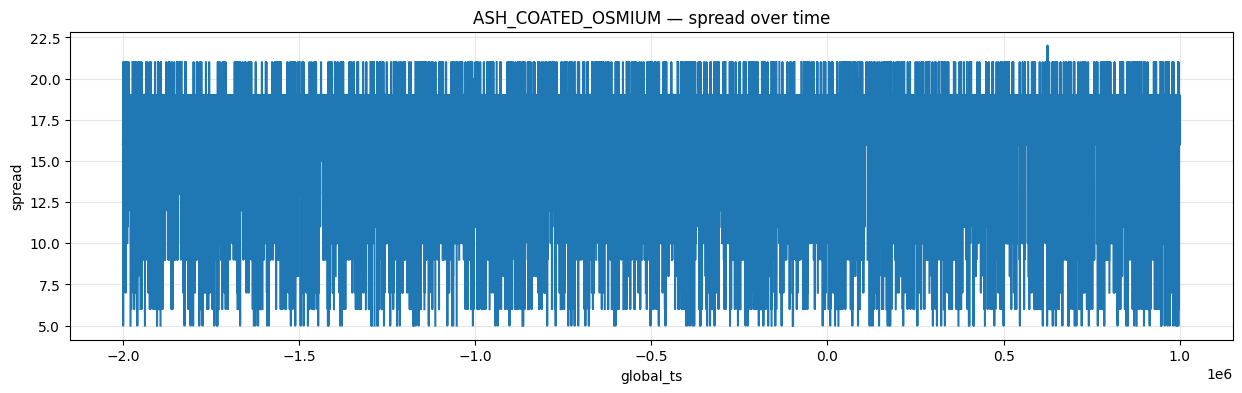

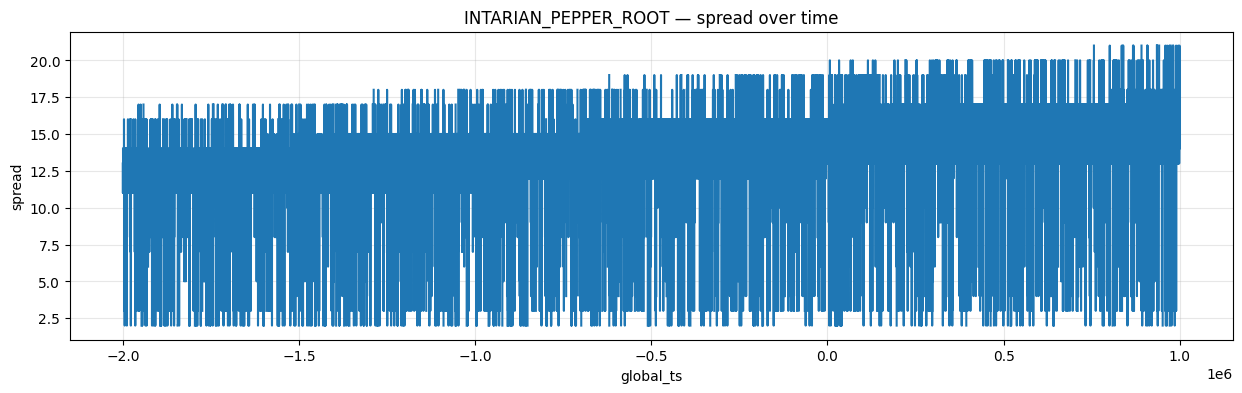

In [72]:
# --- Spread over time ---

for product in PRODUCTS:
    d = fair[fair["product"] == product]

    plt.figure(figsize=(15, 4))
    plt.plot(d["global_ts"], d["spread"])
    plt.title(f"{product} — spread over time")
    plt.xlabel("global_ts")
    plt.ylabel("spread")
    plt.grid(True, alpha=0.3)
    plt.show()

In [73]:
# --- Inside spread opportunity ---

inside_stats = []

for product in PRODUCTS:
    d = fair[fair["product"] == product]

    inside_possible = (d["spread"] >= 2)

    inside_stats.append({
        "product": product,
        "fraction_inside_possible": inside_possible.mean(),
        "num_inside_steps": inside_possible.sum(),
    })

inside_stats = pd.DataFrame(inside_stats)
display(inside_stats)

,product,fraction_inside_possible,num_inside_steps
0,ASH_COATED_OSMIUM,0.921467,27644
1,INTARIAN_PEPPER_ROOT,0.922933,27688


In [74]:
# --- Taker edge relative to mid ---

taker_stats = []

for product in PRODUCTS:
    d = fair[fair["product"] == product]

    # buying at ask vs mid
    buy_edge = d["mid"] - d["best_ask"]

    # selling at bid vs mid
    sell_edge = d["best_bid"] - d["mid"]

    taker_stats.append({
        "product": product,
        "avg_buy_edge": buy_edge.mean(),
        "avg_sell_edge": sell_edge.mean(),
        "worst_buy_edge": buy_edge.min(),
        "worst_sell_edge": sell_edge.min(),
    })

taker_stats = pd.DataFrame(taker_stats)
display(taker_stats)

,product,avg_buy_edge,avg_sell_edge,worst_buy_edge,worst_sell_edge
0,ASH_COATED_OSMIUM,-8.087614,-8.087614,-11.0,-11.0
1,INTARIAN_PEPPER_ROOT,-6.523349,-6.523349,-10.5,-10.5


In [75]:
# --- Detect stale quotes ---

stale_stats = []

for product in PRODUCTS:
    d = fair[fair["product"] == product].copy()

    # future mid movement
    d["mid_next"] = d["mid"].shift(-1)

    # if you buy at ask, does price go up?
    buy_profit = d["mid_next"] - d["best_ask"]

    # if you sell at bid, does price go down?
    sell_profit = d["best_bid"] - d["mid_next"]

    stale_stats.append({
        "product": product,
        "profitable_buy_fraction": (buy_profit > 0).mean(),
        "profitable_sell_fraction": (sell_profit > 0).mean(),
        "avg_buy_profit": buy_profit.mean(),
        "avg_sell_profit": sell_profit.mean(),
    })

stale_stats = pd.DataFrame(stale_stats)
display(stale_stats)

,product,profitable_buy_fraction,profitable_sell_fraction,avg_buy_profit,avg_sell_profit
0,ASH_COATED_OSMIUM,0.013467,0.012067,-8.080608,-8.085733
1,INTARIAN_PEPPER_ROOT,0.015000,0.015133,-6.428719,-6.617890


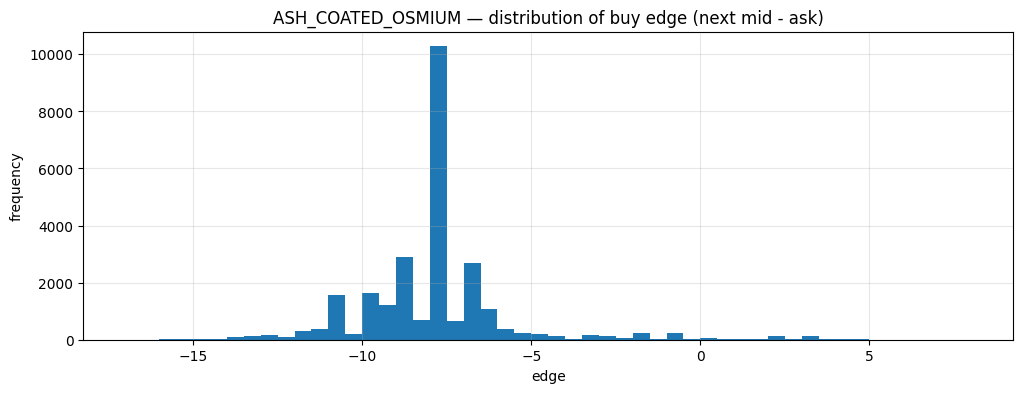

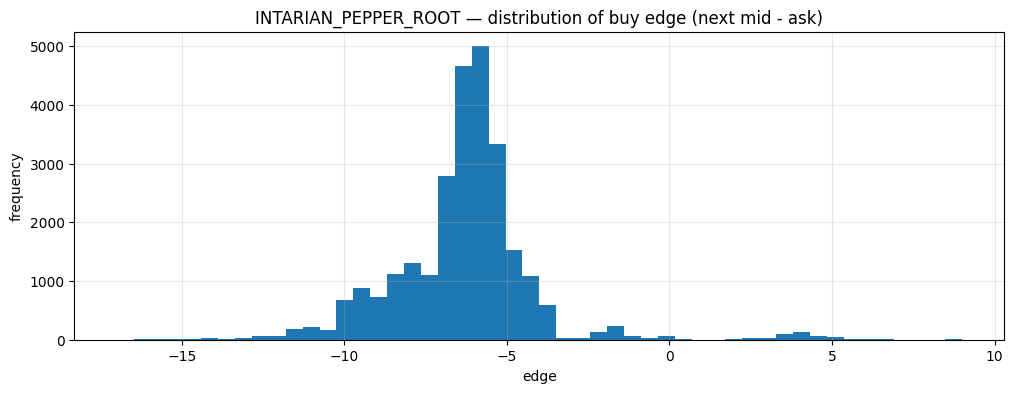

In [76]:
# --- visualize stale edge ---

for product in PRODUCTS:
    d = fair[fair["product"] == product].copy()

    d["buy_edge"] = d["mid"].shift(-1) - d["best_ask"]

    plt.figure(figsize=(12, 4))
    plt.hist(d["buy_edge"].dropna(), bins=50)
    plt.title(f"{product} — distribution of buy edge (next mid - ask)")
    plt.xlabel("edge")
    plt.ylabel("frequency")
    plt.grid(True, alpha=0.3)
    plt.show()

## Inverntory risk

In [77]:
# --- Inventory risk: simulate passive fills ---

inv_df = []

for product in PRODUCTS:
    d = fair[fair["product"] == product].copy()

    # future mids
    d["mid_t+1"] = d["mid"].shift(-1)
    d["mid_t+5"] = d["mid"].shift(-5)

    # BUY at bid → price goes down = bad
    d["buy_pnl_1"] = d["mid_t+1"] - d["best_bid"]
    d["buy_pnl_5"] = d["mid_t+5"] - d["best_bid"]

    # SELL at ask → price goes up = bad
    d["sell_pnl_1"] = d["best_ask"] - d["mid_t+1"]
    d["sell_pnl_5"] = d["best_ask"] - d["mid_t+5"]

    d["product"] = product
    inv_df.append(d)

inv_df = pd.concat(inv_df, ignore_index=True)

In [78]:
# --- Summary stats ---

inventory_stats = []

for product in PRODUCTS:
    d = inv_df[inv_df["product"] == product]

    inventory_stats.append({
        "product": product,

        "buy_winrate_1": (d["buy_pnl_1"] > 0).mean(),
        "sell_winrate_1": (d["sell_pnl_1"] > 0).mean(),

        "buy_winrate_5": (d["buy_pnl_5"] > 0).mean(),
        "sell_winrate_5": (d["sell_pnl_5"] > 0).mean(),

        "avg_buy_pnl_1": d["buy_pnl_1"].mean(),
        "avg_sell_pnl_1": d["sell_pnl_1"].mean(),

        "avg_buy_pnl_5": d["buy_pnl_5"].mean(),
        "avg_sell_pnl_5": d["sell_pnl_5"].mean(),
    })

inventory_stats = pd.DataFrame(inventory_stats)
display(inventory_stats)

,product,buy_winrate_1,sell_winrate_1,buy_winrate_5,sell_winrate_5,avg_buy_pnl_1,avg_sell_pnl_1,avg_buy_pnl_5,avg_sell_pnl_5
0,ASH_COATED_OSMIUM,0.871933,0.869767,0.872100,0.868433,8.085733,8.080608,8.091438,8.079169
1,INTARIAN_PEPPER_ROOT,0.869833,0.870433,0.870767,0.870600,6.617890,6.428719,7.018518,6.022025


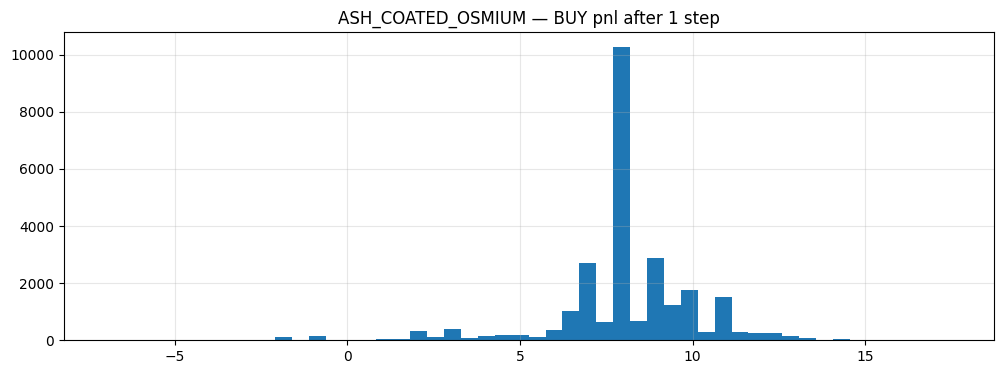

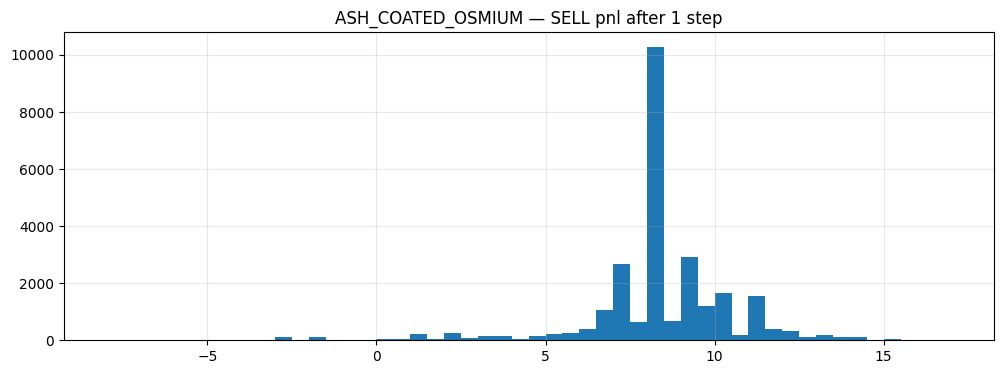

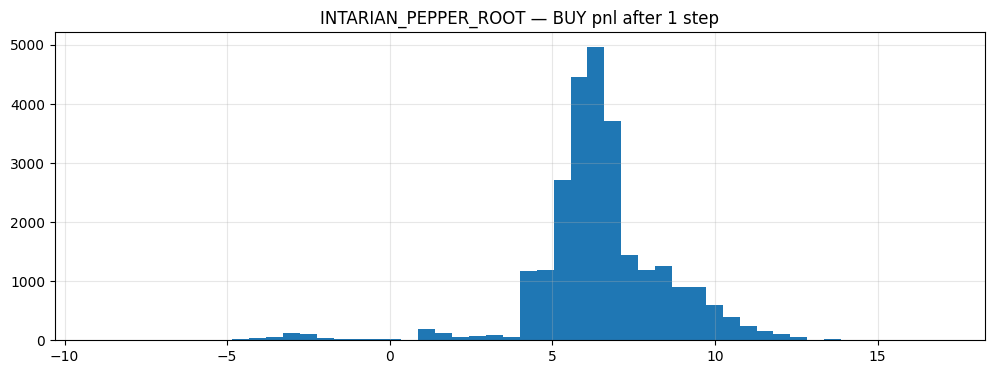

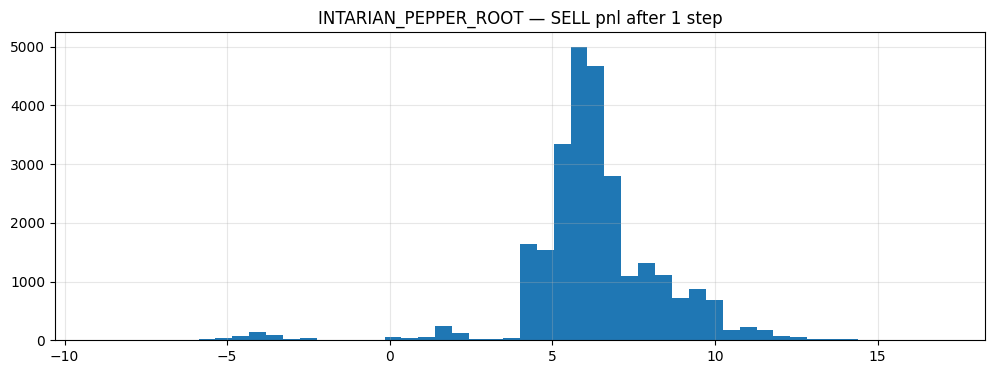

In [79]:
# --- distribution plots ---

for product in PRODUCTS:
    d = inv_df[inv_df["product"] == product]

    plt.figure(figsize=(12, 4))
    plt.hist(d["buy_pnl_1"].dropna(), bins=50)
    plt.title(f"{product} — BUY pnl after 1 step")
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(12, 4))
    plt.hist(d["sell_pnl_1"].dropna(), bins=50)
    plt.title(f"{product} — SELL pnl after 1 step")
    plt.grid(True, alpha=0.3)
    plt.show()

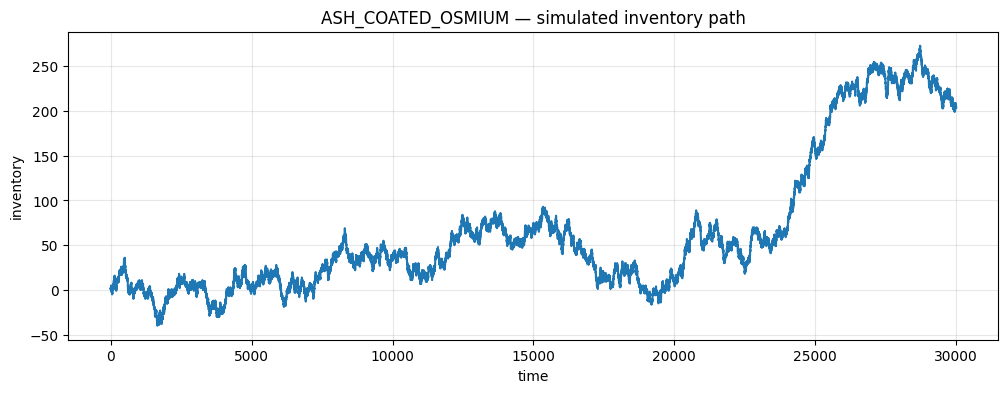

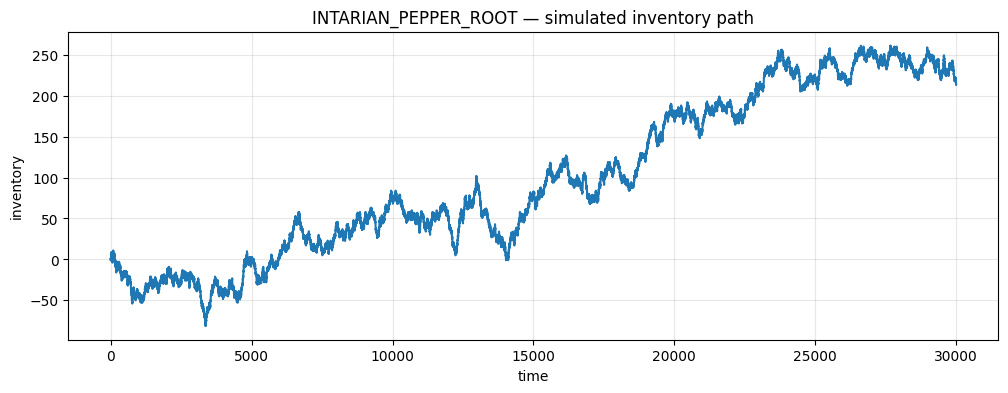

In [80]:
# --- inventory drift proxy ---

for product in PRODUCTS:
    d = inv_df[inv_df["product"] == product].copy()

    # simulate random fills at bid/ask
    # +1 when buy fills, -1 when sell fills
    fills = np.random.choice([-1, 1], size=len(d))

    inventory = np.cumsum(fills)

    plt.figure(figsize=(12, 4))
    plt.plot(inventory)
    plt.title(f"{product} — simulated inventory path")
    plt.xlabel("time")
    plt.ylabel("inventory")
    plt.grid(True, alpha=0.3)
    plt.show()

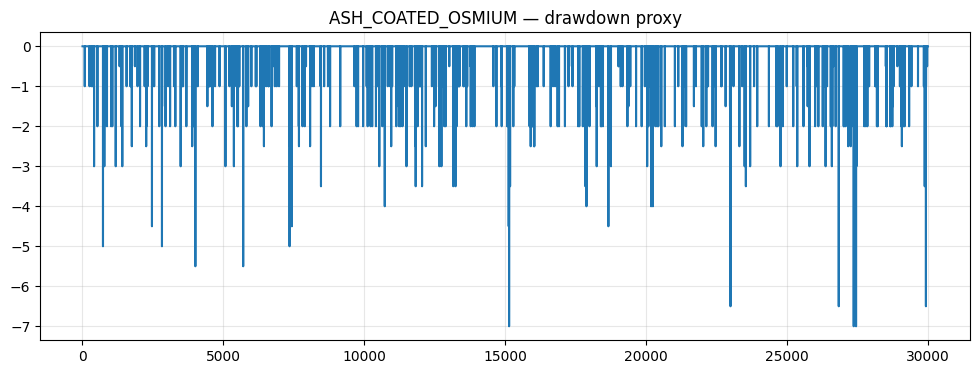

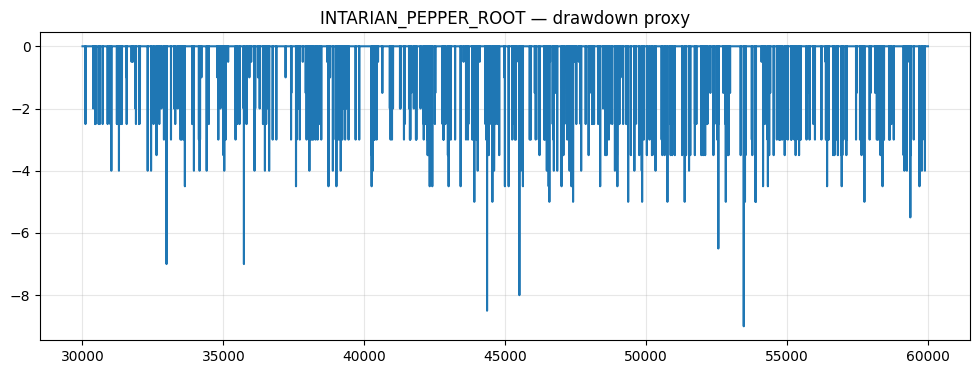

In [81]:
# --- max drawdown style inventory risk ---

for product in PRODUCTS:
    d = inv_df[inv_df["product"] == product]

    pnl_series = d["buy_pnl_1"].fillna(0)  # proxy

    cum_pnl = pnl_series.cumsum()
    running_max = np.maximum.accumulate(cum_pnl)
    drawdown = cum_pnl - running_max

    plt.figure(figsize=(12, 4))
    plt.plot(drawdown)
    plt.title(f"{product} — drawdown proxy")
    plt.grid(True, alpha=0.3)
    plt.show()

## Predictability

In [82]:
# --- Predictability: returns ---

pred_df = []

for product in PRODUCTS:
    d = fair[fair["product"] == product].copy()

    d["mid_ret_1"] = d["mid"].diff()
    d["mid_ret_5"] = d["mid"].diff(5)

    d["mid_next_ret"] = d["mid"].shift(-1) - d["mid"]

    d["product"] = product
    pred_df.append(d)

pred_df = pd.concat(pred_df, ignore_index=True)

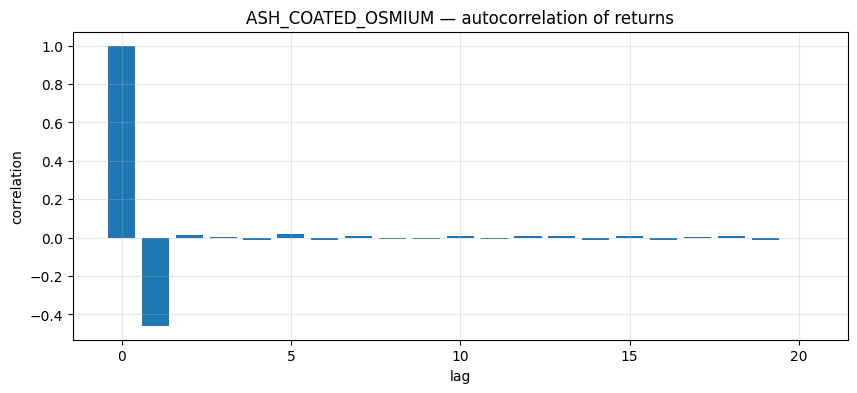

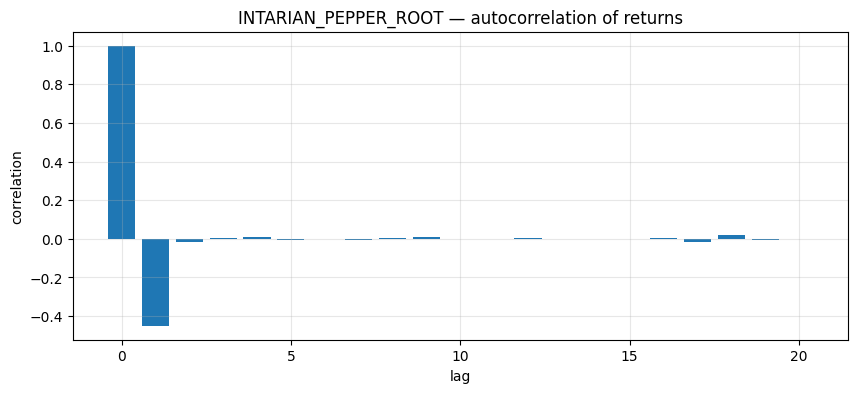

In [83]:
# --- Autocorrelation ---

from statsmodels.tsa.stattools import acf

for product in PRODUCTS:
    d = pred_df[pred_df["product"] == product]["mid_ret_1"].dropna()

    acf_vals = acf(d, nlags=20)

    plt.figure(figsize=(10, 4))
    plt.bar(range(len(acf_vals)), acf_vals)
    plt.title(f"{product} — autocorrelation of returns")
    plt.xlabel("lag")
    plt.ylabel("correlation")
    plt.grid(True, alpha=0.3)
    plt.show()

In [87]:
# --- Sign prediction test (fixed) ---

pred_stats = []

for product in PRODUCTS:
    d = pred_df[pred_df["product"] == product].copy()

    d["pred"] = np.sign(d["mid_ret_1"])
    d["actual"] = np.sign(d["mid_next_ret"])

    # only keep rows where these two are defined
    valid = d[["pred", "actual"]].dropna()

    # optional: exclude zero-return cases to test true directional predictability
    valid_nonzero = valid[(valid["pred"] != 0) & (valid["actual"] != 0)]

    pred_stats.append({
        "product": product,
        "sign_accuracy_all": (valid["pred"] == valid["actual"]).mean() if len(valid) else np.nan,
        "sign_accuracy_nonzero": (valid_nonzero["pred"] == valid_nonzero["actual"]).mean() if len(valid_nonzero) else np.nan,
        "n_all": len(valid),
        "n_nonzero": len(valid_nonzero),
    })

pred_stats = pd.DataFrame(pred_stats)
display(pred_stats)

,product,sign_accuracy_all,sign_accuracy_nonzero,n_all,n_nonzero
0,ASH_COATED_OSMIUM,0.274062,0.237365,23491,11733
1,INTARIAN_PEPPER_ROOT,0.300250,0.241239,23587,9588


In [88]:
# --- Mean reversion test (fixed) ---

mr_stats = []

for product in PRODUCTS:
    d = pred_df[pred_df["product"] == product].copy()

    d["reversion_signal"] = -np.sign(d["mid_ret_1"])
    d["actual"] = np.sign(d["mid_next_ret"])

    valid = d[["reversion_signal", "actual"]].dropna()
    valid_nonzero = valid[(valid["reversion_signal"] != 0) & (valid["actual"] != 0)]

    mr_stats.append({
        "product": product,
        "mean_reversion_accuracy_all": (valid["reversion_signal"] == valid["actual"]).mean() if len(valid) else np.nan,
        "mean_reversion_accuracy_nonzero": (valid_nonzero["reversion_signal"] == valid_nonzero["actual"]).mean() if len(valid_nonzero) else np.nan,
        "n_all": len(valid),
        "n_nonzero": len(valid_nonzero),
    })

mr_stats = pd.DataFrame(mr_stats)
display(mr_stats)

,product,mean_reversion_accuracy_all,mean_reversion_accuracy_nonzero,n_all,n_nonzero
0,ASH_COATED_OSMIUM,0.536418,0.762635,23491,11733
1,INTARIAN_PEPPER_ROOT,0.510620,0.758761,23587,9588


In [89]:
# --- Conditional expectation (clean version) ---

cond_stats = []

for product in PRODUCTS:
    d = pred_df[pred_df["product"] == product].copy()

    up = d.loc[d["mid_ret_1"] > 0, "mid_next_ret"].mean()
    down = d.loc[d["mid_ret_1"] < 0, "mid_next_ret"].mean()
    zero = d.loc[d["mid_ret_1"] == 0, "mid_next_ret"].mean()

    cond_stats.append({
        "product": product,
        "E[next_ret | current_ret > 0]": up,
        "E[next_ret | current_ret < 0]": down,
        "E[next_ret | current_ret = 0]": zero,
    })

cond_stats = pd.DataFrame(cond_stats)
display(cond_stats)

,product,E[next_ret | current_ret > 0],E[next_ret | current_ret < 0],E[next_ret | current_ret = 0]
0,ASH_COATED_OSMIUM,-0.895520,0.914879,0.01102
1,INTARIAN_PEPPER_ROOT,-0.611118,1.130070,0.07714
